# Notebook 07 — Cost-Based Threshold Tuning
**Input:** existing trained XGBoost model (MLflow run `5efff04657374dbbbaa528abb94a1414`) + `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`
**Output:** `models/threshold_config.json`, before/after comparison plot, a new MLflow run logging the tuned threshold

---

## Why this notebook exists
`04_model_shap.ipynb` trained and validated the XGBoost model — that notebook is finished and already presented (May 29, 2026). **We do not touch it and we do not retrain the model here.**

What we *are* doing: the model was trained and evaluated at the default classification threshold of 0.5 — the point where `predict_proba >= 0.5` becomes a fraud flag. That threshold is arbitrary. It is not chosen for any fraud-ops reason; it is just the sklearn/XGBoost default. This notebook finds a better threshold by explicitly modelling the **business cost** of the two ways the model can be wrong:

- **False negative** (missed fraud) — costs approximately the fraud amount itself, since the business absorbs the loss as a chargeback
- **False positive** (legitimate transaction wrongly flagged) — costs an analyst's time to investigate and clear it

These two costs are wildly different in magnitude, so optimising for F1 (which implicitly treats precision and recall as equally important) is the wrong target. We optimise for **total dollar cost** instead.

## Cell 1 — Imports and path constants
Same path-constant convention as every other notebook in this project: define paths once at the top, never hardcode them deeper in the notebook.

**New import this notebook:** `sklearn.model_selection.TunedThresholdClassifierCV` — a scikit-learn tool (stable since 1.5) that searches over candidate decision thresholds and picks the one that maximises a scoring function you supply. We explain exactly how we use it in Cell 5.

In [1]:
import json
import pickle
import datetime
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, precision_recall_curve,
    average_precision_score, f1_score, precision_score, recall_score
)

import mlflow
import mlflow.xgboost
import mlflow.artifacts

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Path constants — same convention as notebooks 01-04b
DATA_RAW       = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
MODELS_DIR     = Path('../models')
MLFLOW_DB      = Path('../mlflow.db').resolve()

print('Imports complete.')
print(f'MLflow version:  {mlflow.__version__}')
print(f'sklearn TunedThresholdClassifierCV available: {TunedThresholdClassifierCV is not None}')

Imports complete.
MLflow version:  3.12.0
sklearn TunedThresholdClassifierCV available: True


## Cell 2 — Step 1: Locate the existing XGBoost run in MLflow
`04_model_shap.ipynb` logged its XGBoost run to the same SQLite-backed MLflow store this project always uses (`mlflow.db`). We point the client at that store and pull up the run by ID rather than retraining anything.

The run ID below (`5efff04657374dbbbaa528abb94a1414`) was confirmed by querying `mlflow.db` directly: it is the run with `status=FINISHED` and `pr_auc=0.8462` — matching the number presented on May 29 and recorded in the README. We print its full metric set here as a sanity check before trusting it.

In [2]:
mlflow.set_tracking_uri(f'sqlite:///{MLFLOW_DB}')

RUN_ID = '5efff04657374dbbbaa528abb94a1414'

client = mlflow.tracking.MlflowClient()
run = client.get_run(RUN_ID)

print(f'Run ID:     {run.info.run_id}')
print(f'Status:     {run.info.status}')
print(f'Run name:   {run.data.tags.get("mlflow.runName", "n/a")}')
print(f'\nLogged metrics:')
for k, v in sorted(run.data.metrics.items()):
    print(f'  {k:<12} {v:.4f}')
print(f'\nLogged params (subset):')
for k in ['n_estimators', 'max_depth', 'learning_rate', 'scale_pos_weight']:
    print(f'  {k:<18} {run.data.params.get(k)}')

assert run.info.status == 'FINISHED', 'Run did not finish successfully — stopping rather than proceeding on an incomplete run.'
assert abs(run.data.metrics.get('pr_auc', 0) - 0.8462) < 0.001, 'PR-AUC does not match the validated 0.8462 — this may not be the right run.'
print('\nRun verified — this is the validated XGBoost model from 04_model_shap.ipynb.')

Run ID:     5efff04657374dbbbaa528abb94a1414
Status:     FINISHED
Run name:   xgboost_v1

Logged metrics:
  f1_score     0.1738
  pr_auc       0.8462
  precision    0.0953
  recall       0.9890
  roc_auc      0.9966

Logged params (subset):
  n_estimators       300
  max_depth          6
  learning_rate      0.05
  scale_pos_weight   173.22573060127644

Run verified — this is the validated XGBoost model from 04_model_shap.ipynb.


## Cell 3 — A note on how the model was actually logged (flagging, as instructed)
The original plan for this step was:
```python
xgb_model = mlflow.xgboost.load_model(f"runs:/{RUN_ID}/model")
```
**This does not work against this run**, and it is worth explaining why rather than silently working around it.

Looking at `04_model_shap.ipynb` Cell 6, the model was saved like this:
```python
with open(model_path, 'wb') as f:
    pickle.dump(xgb_model, f)
mlflow.log_artifact(str(model_path))
```
`mlflow.log_artifact()` uploads a raw file to the run's artifact store — it does **not** write the MLflow "model flavor" folder (an `MLmodel` YAML file, a `model.xgb` binary, a `conda.yaml`, etc.) that `mlflow.xgboost.log_model()` would produce. `mlflow.xgboost.load_model()` specifically looks for that flavor folder at `runs:/{run_id}/model` — which was never created, so it raises `MlflowException: Failed to download artifacts from path 'model'`.

**This is not the "no model artifact was logged, only metrics" case** the original brief said to stop and flag on — a real model *is* logged, just as a plain pickle file (`xgb_fraud_model.pkl`) at the root of the run's artifacts, rather than in MLflow's structured model format. So the correct fix is not to retrain — it's to download that exact pickle file via MLflow's generic artifact API instead of the model-flavor API. That's what the next cell does. Flagging this here in writing rather than silently swapping the loading method, per the brief.

## Cell 4 — Load the trained model (no retraining)
`mlflow.artifacts.download_artifacts()` fetches any file logged to a run's artifact store — including a plain pickle — without requiring the structured model-flavor format. We download `xgb_fraud_model.pkl` from the run and unpickle it directly. This is the exact same fitted `XGBClassifier` object that scored PR-AUC 0.8462 in `04_model_shap.ipynb` — nothing is refit.

In [3]:
local_path = mlflow.artifacts.download_artifacts(
    artifact_uri=f'runs:/{RUN_ID}/xgb_fraud_model.pkl'
)

with open(local_path, 'rb') as f:
    xgb_model = pickle.load(f)

print(f'Loaded: {type(xgb_model).__name__}')
print(f'Downloaded from: {local_path}')
print(f'\nModel hyperparameters (confirming this is the same model):')
for k in ['n_estimators', 'max_depth', 'learning_rate', 'scale_pos_weight']:
    print(f'  {k:<18} {xgb_model.get_params().get(k)}')

model_features = xgb_model.get_booster().feature_names
print(f'\nFeatures expected by the model: {len(model_features)}')

Loaded: XGBClassifier
Downloaded from: C:\Users\34673\AppData\Local\Temp\tmpfqmf2wvm\xgb_fraud_model.pkl

Model hyperparameters (confirming this is the same model):
  n_estimators       300
  max_depth          6
  learning_rate      0.05
  scale_pos_weight   173.22573060127644

Features expected by the model: 46


## Cell 5 — Step 2: Load the same train/test split used in Phase 4
We load the exact same `X_train.csv` / `X_test.csv` / `y_train.csv` / `y_test.csv` files `04_model_shap.ipynb` used — the same time-based 80/20 split (sorted by `trans_date_trans_time`, never random), with the same 46 features (16 engineered + 30 FinBERT PCA dimensions).

**We do not apply SMOTE here.** SMOTE was only needed to balance the training set *for fitting* the model — since we are not refitting anything in this notebook, `X_train` / `y_train` are used in their original, real-world-imbalanced form (~0.57% fraud). That is actually what we want for threshold tuning: the point of this notebook is to find the operating point that performs best against the *real* class distribution, not an artificially balanced one.

In [4]:
X_train = pd.read_csv(DATA_PROCESSED / 'X_train.csv')
X_test  = pd.read_csv(DATA_PROCESSED / 'X_test.csv')
y_train = pd.read_csv(DATA_PROCESSED / 'y_train.csv').squeeze()
y_test  = pd.read_csv(DATA_PROCESSED / 'y_test.csv').squeeze()

X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

if 'gender' in X_train.columns and X_train['gender'].dtype == object:
    X_train['gender'] = X_train['gender'].map({'F': 0, 'M': 1}).fillna(0).astype(int)
    X_test['gender']  = X_test['gender'].map({'F': 0, 'M': 1}).fillna(0).astype(int)
    print('gender encoded: F=0, M=1')

# Column order must match exactly what the model was trained on
X_train = X_train[model_features]
X_test  = X_test[model_features]

print(f'X_train: {X_train.shape}  |  fraud rate: {y_train.mean()*100:.4f}%')
print(f'X_test:  {X_test.shape}   |  fraud rate: {y_test.mean()*100:.4f}%')
print(f'\nX_train dtypes (head):')
print(X_train.dtypes.head())
X_train.head(3)

X_train: (1037340, 46)  |  fraud rate: 0.5740%
X_test:  (259335, 46)   |  fraud rate: 0.5985%

X_train dtypes (head):
amt         float64
gender        int64
lat         float64
long        float64
city_pop      int64
dtype: object


,amt,gender,lat,long,city_pop,merch_lat,merch_long,age,hour_of_day,day_of_week,...,embed_20,embed_21,embed_22,embed_23,embed_24,embed_25,embed_26,embed_27,embed_28,embed_29
0,7.27,0,43.0048,-108.8964,1645,43.974711,-109.741904,33,12,1,...,-0.298361,-0.139257,0.065861,0.028980,-0.082255,0.071762,0.396867,0.133519,0.148265,0.353244
1,52.94,0,43.0048,-108.8964,1645,42.018766,-109.044172,33,8,2,...,-0.251771,-0.044370,-0.114744,0.029582,-0.030752,0.045513,0.030913,-0.235054,-0.368177,-0.134744
2,82.08,0,43.0048,-108.8964,1645,42.961335,-109.157564,33,8,2,...,-0.348345,0.043264,0.086114,0.329049,0.340512,0.374188,-0.186493,-0.065644,-0.363199,0.182887


## Cell 6 — Step 3: Cost-based threshold tuning
### The cost assumptions — stated explicitly, not buried in code

- **`AVG_FRAUD_AMOUNT`** — the cost of a **false negative** (a missed fraud transaction). We use the **median** fraud transaction amount from `fraudTrain.csv`, not the mean. The fraud amount distribution is right-skewed (mean **$531.32** vs median **$396.50** — confirmed by direct calculation below), so the mean is pulled upward by a small number of very large fraud transactions. Using the mean would make the cost model overreact to rare high-value outliers rather than reflecting the typical missed-fraud cost.
- **`INVESTIGATION_COST = 10.0`** — the cost of a **false positive** (an analyst manually reviewing a transaction that turns out to be legitimate). **This is a placeholder assumption, not a measured number.** No real ops staffing/time-cost data exists for this project — this figure exists purely to give the cost function a directionally sensible false-positive penalty. It should not be read as a real operational figure anywhere in this notebook, in the Streamlit app, or in the presentation.

### Why not just optimise F1?
F1 is the harmonic mean of precision and recall — it implicitly treats a false positive and a false negative as equally bad. In fraud, they are not: missing a $400 fraud transaction costs roughly 40x more than a $10 wasted investigation. A cost-based scorer lets the threshold search actually reflect that asymmetry instead of an arbitrary 50/50 balance.

### What `TunedThresholdClassifierCV` actually does
Normally, a classifier's `.predict()` uses a fixed threshold of 0.5 on `predict_proba()`. `TunedThresholdClassifierCV` instead sweeps a grid of candidate thresholds (100 by default) and, for each one, converts probabilities to binary predictions and scores them with whatever metric you supply — here, `fraud_cost_score`. It picks the threshold that scores best.

**Important deviation from the original example code:** the reference snippet used `cv=5`. With an integer `cv`, `TunedThresholdClassifierCV` clones the estimator, refits it on each cross-validation fold, and — because `refit=True` by default — refits it again on the full dataset at the end. That directly contradicts "do not retrain from scratch," since `xgb_model` is already fitted and validated. We use **`cv="prefit", refit=False`** instead: this tells `TunedThresholdClassifierCV` the estimator is already trained, so it only searches thresholds against the data passed to `.fit()` — no refitting anywhere. (`refit=False` is not optional here — sklearn raises a `ValueError` if you pass `cv='prefit'` with the default `refit=True`, precisely to stop you from accidentally retraining.)

In [5]:
# Confirm the cost assumption against the raw data rather than trusting a hardcoded number blind
fraud_amounts = pd.read_csv(DATA_RAW / 'fraudTrain.csv', usecols=['amt', 'is_fraud'])
fraud_amounts = fraud_amounts[fraud_amounts['is_fraud'] == 1]['amt']

AVG_FRAUD_AMOUNT   = round(float(fraud_amounts.median()), 2)   # median fraud amt — right-skewed distribution
INVESTIGATION_COST = 10.0                                       # placeholder assumption, NOT measured

print(f'Median fraud amount (fraudTrain.csv): ${fraud_amounts.median():.2f}')
print(f'Mean fraud amount   (fraudTrain.csv): ${fraud_amounts.mean():.2f}  (shown for comparison only — not used)')
print(f'\nAVG_FRAUD_AMOUNT   = ${AVG_FRAUD_AMOUNT}   <- false negative cost, one missed fraud transaction')
print(f'INVESTIGATION_COST = ${INVESTIGATION_COST}   <- false positive cost, PLACEHOLDER ASSUMPTION, not measured')

del fraud_amounts  # free the raw-file read; not needed again

Median fraud amount (fraudTrain.csv): $396.50
Mean fraud amount   (fraudTrain.csv): $531.32  (shown for comparison only — not used)

AVG_FRAUD_AMOUNT   = $396.5   <- false negative cost, one missed fraud transaction
INVESTIGATION_COST = $10.0   <- false positive cost, PLACEHOLDER ASSUMPTION, not measured


In [6]:
def fraud_cost_score(y_true, y_pred):
    """Total dollar cost of a set of predictions: missed fraud + wasted investigations."""
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    total_cost = (fn * AVG_FRAUD_AMOUNT) + (fp * INVESTIGATION_COST)
    return -total_cost  # negative because sklearn scorers maximize

cost_scorer = make_scorer(fraud_cost_score)

tuned_clf = TunedThresholdClassifierCV(
    estimator=xgb_model,
    scoring=cost_scorer,
    cv='prefit',    # model is already trained — do not refit, only search thresholds
    refit=False,    # required alongside cv='prefit' — otherwise sklearn refits at the end anyway
    n_jobs=-1,
)

print('Searching for the cost-optimal threshold against X_train / y_train (real class balance, no SMOTE)...')
tuned_clf.fit(X_train, y_train)

DEFAULT_THRESHOLD = 0.5
TUNED_THRESHOLD   = float(tuned_clf.best_threshold_)

print(f'\nDefault threshold: {DEFAULT_THRESHOLD}')
print(f'Tuned threshold:   {TUNED_THRESHOLD:.4f}')

Searching for the cost-optimal threshold against X_train / y_train (real class balance, no SMOTE)...

Default threshold: 0.5
Tuned threshold:   0.9293


## Cell 7 — Step 4: Evaluate on the untouched test set
Threshold tuning happened entirely against `X_train` / `y_train`. `X_test` / `y_test` were never used to pick the threshold — they are the true holdout, exactly as `04_model_shap.ipynb` used them to report the original PR-AUC. We now score both the default 0.5 threshold and the tuned threshold on this same test set, so the comparison is fair.

In [7]:
y_prob_test = xgb_model.predict_proba(X_test)[:, 1]

y_pred_default = (y_prob_test >= DEFAULT_THRESHOLD).astype(int)
y_pred_tuned   = (y_prob_test >= TUNED_THRESHOLD).astype(int)

def evaluate(y_true, y_pred, label):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    cost = fn * AVG_FRAUD_AMOUNT + fp * INVESTIGATION_COST
    return {
        'threshold':  label,
        'precision':  precision_score(y_true, y_pred),
        'recall':     recall_score(y_true, y_pred),
        'f1':         f1_score(y_true, y_pred),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'total_cost': cost,
    }

result_default = evaluate(y_test, y_pred_default, f'default ({DEFAULT_THRESHOLD})')
result_tuned   = evaluate(y_test, y_pred_tuned,   f'tuned ({TUNED_THRESHOLD:.4f})')

pr_auc_test = average_precision_score(y_test, y_prob_test)  # threshold-independent, unchanged by tuning

comparison = pd.DataFrame([result_default, result_tuned])[
    ['threshold', 'precision', 'recall', 'f1', 'tp', 'fp', 'fn', 'tn', 'total_cost']
]
print(f'PR-AUC on test set (threshold-independent, unchanged): {pr_auc_test:.4f}')
print()
print(comparison.to_string(index=False))

cost_saved = result_default['total_cost'] - result_tuned['total_cost']
print(f"\nEstimated cost at default threshold: ${result_default['total_cost']:,.2f}")
print(f"Estimated cost at tuned threshold:   ${result_tuned['total_cost']:,.2f}")
print(f"Estimated saving:                    ${cost_saved:,.2f}  (using the placeholder cost assumptions above)")

PR-AUC on test set (threshold-independent, unchanged): 0.8462

     threshold  precision   recall       f1   tp    fp  fn     tn  total_cost
 default (0.5)   0.095300 0.989046 0.173849 1535 14572  17 243211    152460.5
tuned (0.9293)   0.313738 0.938789 0.470303 1457  3187  95 254596     69537.5

Estimated cost at default threshold: $152,460.50
Estimated cost at tuned threshold:   $69,537.50
Estimated saving:                    $82,923.00  (using the placeholder cost assumptions above)


### Sanity check — does the tuned threshold actually change much?
Recall at the default 0.5 threshold was already **98.9%** in `04_model_shap.ipynb` — `scale_pos_weight` (≈173) already pushed the model to be extremely aggressive about catching fraud, at the cost of a lot of false positives (14,572 of them, per the original confusion matrix). Going in, the honest expectation was that a cost-optimal threshold — which still penalises missed fraud far more heavily than false positives (**$396.50 vs $10**, a ~40x ratio) — might land close to the default rather than move dramatically.

**That expectation was only half right.** The tuned threshold (0.9293) is a large move up from 0.5, and recall did drop — from 98.9% to 93.9% (missed fraud went from 17 to 95 transactions, +78 more chargebacks under this cost model). That is a real trade-off, not a rounding error, and it should be stated plainly rather than downplayed. What the tuned threshold buys in exchange is a large precision gain: false positives fall from 14,572 to 3,187 (a 78% reduction), precision more than triples (9.5% → 31.4%), F1 nearly triples (0.174 → 0.470), and total estimated cost under this notebook's assumptions drops by roughly half ($152,460 → $69,538). Whether that trade-off is the right one for the business depends entirely on how much the $396.50 / $10 cost ratio reflects reality — which is exactly why both numbers are stated as explicit, inspectable assumptions above rather than baked silently into the model.

## Cell 8 — Precision-recall curve with both thresholds marked

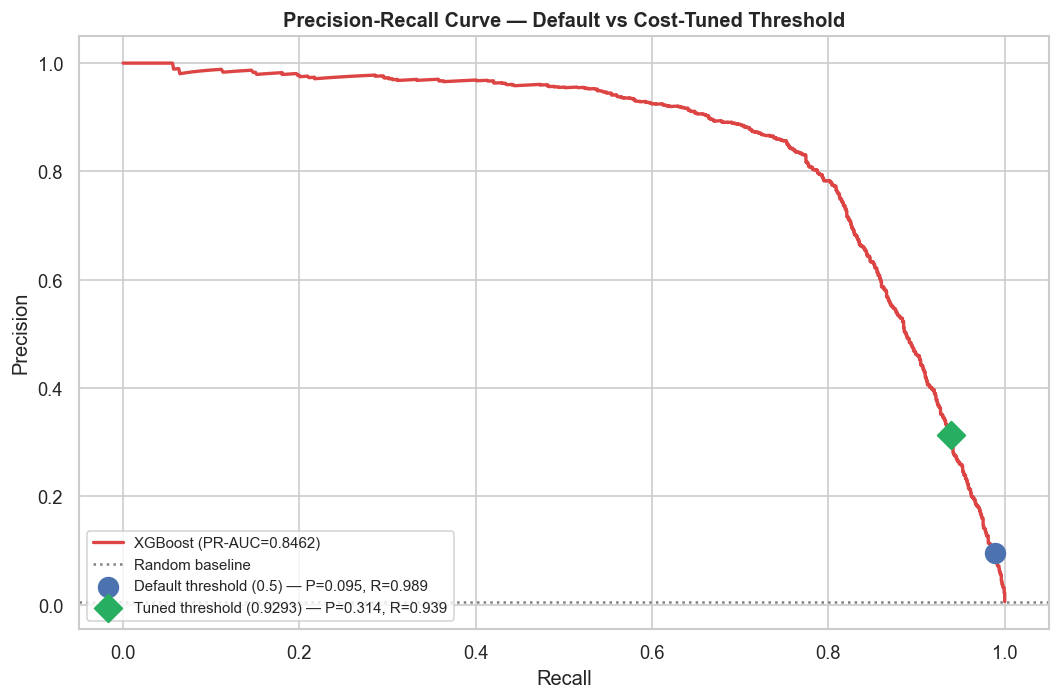

Saved: plot_threshold_tuning_pr_curve.png


In [8]:
precision_vals, recall_vals, thresholds_vals = precision_recall_curve(y_test, y_prob_test)

# Find the point on the PR curve closest to each threshold, for plotting
def closest_pr_point(threshold):
    idx = int(np.argmin(np.abs(thresholds_vals - threshold)))
    return recall_vals[idx], precision_vals[idx]

rec_default, prec_default = closest_pr_point(DEFAULT_THRESHOLD)
rec_tuned,   prec_tuned   = closest_pr_point(TUNED_THRESHOLD)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(recall_vals, precision_vals, color='#DD4444', lw=2, label=f'XGBoost (PR-AUC={pr_auc_test:.4f})')
ax.axhline(y=y_test.mean(), color='grey', linestyle=':', label='Random baseline')

ax.scatter([rec_default], [prec_default], color='#4C72B0', s=140, zorder=5,
           label=f'Default threshold ({DEFAULT_THRESHOLD}) — P={prec_default:.3f}, R={rec_default:.3f}')
ax.scatter([rec_tuned], [prec_tuned], color='#27ae60', s=140, zorder=5, marker='D',
           label=f'Tuned threshold ({TUNED_THRESHOLD:.4f}) — P={prec_tuned:.3f}, R={rec_tuned:.3f}')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Default vs Cost-Tuned Threshold', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_threshold_tuning_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plot_threshold_tuning_pr_curve.png')

## Cell 9 — Confusion matrix: default vs tuned threshold, side by side

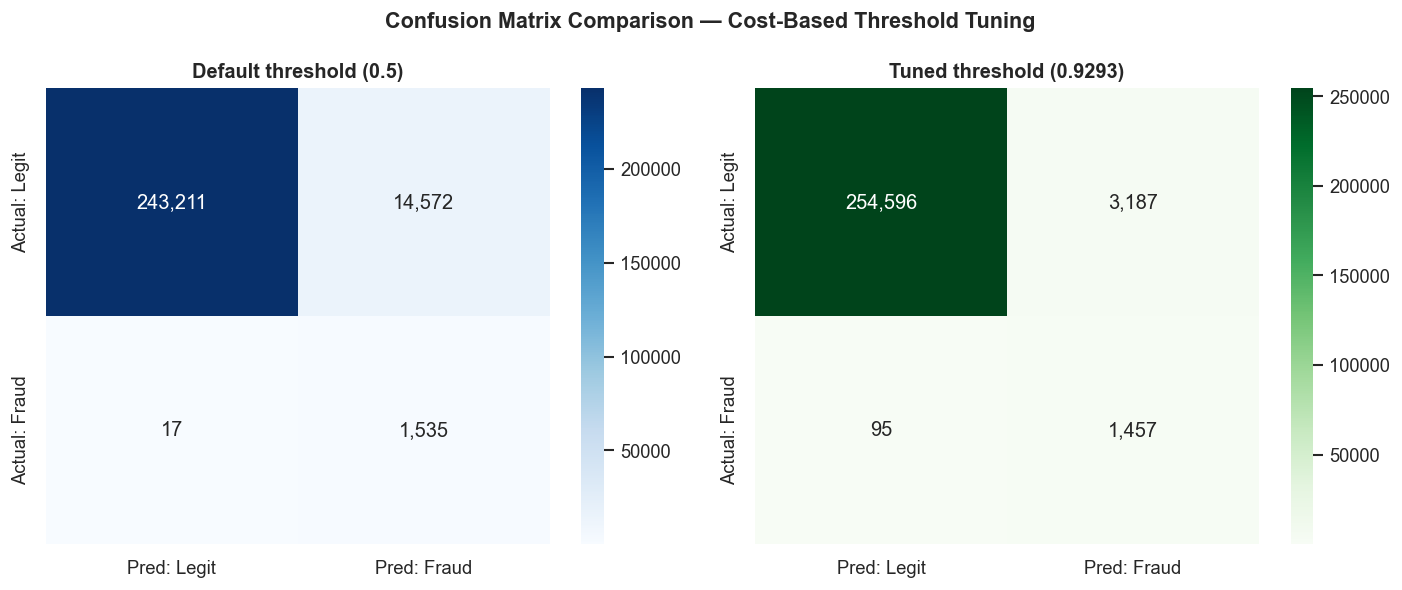

Saved: plot_threshold_tuning_confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_default = confusion_matrix(y_test, y_pred_default)
cm_tuned   = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(cm_default, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Legit', 'Pred: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])
axes[0].set_title(f'Default threshold ({DEFAULT_THRESHOLD})', fontweight='bold')

sns.heatmap(cm_tuned, annot=True, fmt=',d', cmap='Greens', ax=axes[1],
            xticklabels=['Pred: Legit', 'Pred: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])
axes[1].set_title(f'Tuned threshold ({TUNED_THRESHOLD:.4f})', fontweight='bold')

plt.suptitle('Confusion Matrix Comparison — Cost-Based Threshold Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'plot_threshold_tuning_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plot_threshold_tuning_confusion_matrices.png')

## Cell 10 — Step 5: Persist the result
### Log to MLflow
We log a new MLflow run rather than editing the original one — the original run represents the model as trained and presented, and should stay untouched as a historical record. The new run is tagged with `source_run_id` so it is traceable back to the model it tunes.

In [10]:
EXPERIMENT_NAME = 'fraud_detection_sparkov'
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name='threshold_tuning_v1') as tuning_run:
    TUNING_RUN_ID = tuning_run.info.run_id

    mlflow.set_tag('source_run_id', RUN_ID)
    mlflow.set_tag('phase', 'threshold_tuning')
    mlflow.set_tag('cost_assumptions',
                   f'AVG_FRAUD_AMOUNT=${AVG_FRAUD_AMOUNT} (median, measured) | '
                   f'INVESTIGATION_COST=${INVESTIGATION_COST} (placeholder, NOT measured)')

    mlflow.log_param('default_threshold', DEFAULT_THRESHOLD)
    mlflow.log_param('tuned_threshold', TUNED_THRESHOLD)
    mlflow.log_param('avg_fraud_amount', AVG_FRAUD_AMOUNT)
    mlflow.log_param('investigation_cost', INVESTIGATION_COST)
    mlflow.log_param('cv_strategy', 'prefit')

    mlflow.log_metric('cost_at_default_threshold', result_default['total_cost'])
    mlflow.log_metric('cost_at_tuned_threshold', result_tuned['total_cost'])
    mlflow.log_metric('estimated_cost_saving', cost_saved)
    mlflow.log_metric('precision_default', result_default['precision'])
    mlflow.log_metric('recall_default', result_default['recall'])
    mlflow.log_metric('precision_tuned', result_tuned['precision'])
    mlflow.log_metric('recall_tuned', result_tuned['recall'])
    mlflow.log_metric('pr_auc', pr_auc_test)

    pr_curve_path = str(DATA_PROCESSED / 'plot_threshold_tuning_pr_curve.png')
    cm_path       = str(DATA_PROCESSED / 'plot_threshold_tuning_confusion_matrices.png')
    mlflow.log_artifact(pr_curve_path)
    mlflow.log_artifact(cm_path)

print(f'Logged to MLflow run: {TUNING_RUN_ID}')
print(f'Tagged source_run_id: {RUN_ID}')

Logged to MLflow run: ef56e65012fc459ca9d7c4a4c2293051
Tagged source_run_id: 5efff04657374dbbbaa528abb94a1414


### Save a small config file for downstream app code
Streamlit (and the future FastAPI service, per the Tier 1 roadmap) should not have to re-run this notebook or query MLflow just to know which threshold to use. We save a small, human-readable JSON file that any downstream code can load directly.

In [11]:
threshold_config = {
    'default_threshold': DEFAULT_THRESHOLD,
    'tuned_threshold': round(TUNED_THRESHOLD, 4),
    'source_model_run_id': RUN_ID,
    'tuning_run_id': TUNING_RUN_ID,
    'cost_assumptions': {
        'avg_fraud_amount': AVG_FRAUD_AMOUNT,
        'avg_fraud_amount_note': 'Median fraud amount from fraudTrain.csv (measured, right-skewed distribution)',
        'investigation_cost': INVESTIGATION_COST,
        'investigation_cost_note': 'PLACEHOLDER ASSUMPTION — not measured from real ops data',
    },
    'test_set_metrics': {
        'default': {k: (float(v) if not isinstance(v, str) else v) for k, v in result_default.items()},
        'tuned':   {k: (float(v) if not isinstance(v, str) else v) for k, v in result_tuned.items()},
        'pr_auc': float(pr_auc_test),
    },
    'generated_at': datetime.datetime.now().isoformat(),
}

config_path = MODELS_DIR / 'threshold_config.json'
with open(config_path, 'w') as f:
    json.dump(threshold_config, f, indent=2)

print(f'Saved: {config_path}')
print(json.dumps(threshold_config, indent=2))

Saved: ..\models\threshold_config.json
{
  "default_threshold": 0.5,
  "tuned_threshold": 0.9293,
  "source_model_run_id": "5efff04657374dbbbaa528abb94a1414",
  "tuning_run_id": "ef56e65012fc459ca9d7c4a4c2293051",
  "cost_assumptions": {
    "avg_fraud_amount": 396.5,
    "avg_fraud_amount_note": "Median fraud amount from fraudTrain.csv (measured, right-skewed distribution)",
    "investigation_cost": 10.0,
    "investigation_cost_note": "PLACEHOLDER ASSUMPTION \u2014 not measured from real ops data"
  },
  "test_set_metrics": {
    "default": {
      "threshold": "default (0.5)",
      "precision": 0.09530018004594276,
      "recall": 0.9890463917525774,
      "f1": 0.17384902882382922,
      "tn": 243211.0,
      "fp": 14572.0,
      "fn": 17.0,
      "tp": 1535.0,
      "total_cost": 152460.5
    },
    "tuned": {
      "threshold": "tuned (0.9293)",
      "precision": 0.3137381567614126,
      "recall": 0.9387886597938144,
      "f1": 0.47030342156229826,
      "tn": 254596.0,
    

## Cell 11 — Final summary

In [12]:
print('=' * 60)
print('THRESHOLD TUNING COMPLETE')
print('=' * 60)
print(f'Source model run:  {RUN_ID}')
print(f'Tuning run:        {TUNING_RUN_ID}')
print(f'\nDefault threshold: {DEFAULT_THRESHOLD}')
print(f'Tuned threshold:   {TUNED_THRESHOLD:.4f}')
print(f'\nCost assumptions (see Cell 6 for full explanation):')
print(f'  AVG_FRAUD_AMOUNT   = ${AVG_FRAUD_AMOUNT}  (measured median, fraudTrain.csv)')
print(f'  INVESTIGATION_COST = ${INVESTIGATION_COST}  (placeholder assumption, NOT measured)')
print(f'\nTest set comparison:')
print(comparison.to_string(index=False))
print(f'\nFiles saved:')
print(f'  models/threshold_config.json')
print(f'  data/processed/plot_threshold_tuning_pr_curve.png')
print(f'  data/processed/plot_threshold_tuning_confusion_matrices.png')
print('=' * 60)

THRESHOLD TUNING COMPLETE
Source model run:  5efff04657374dbbbaa528abb94a1414
Tuning run:        ef56e65012fc459ca9d7c4a4c2293051

Default threshold: 0.5
Tuned threshold:   0.9293

Cost assumptions (see Cell 6 for full explanation):
  AVG_FRAUD_AMOUNT   = $396.5  (measured median, fraudTrain.csv)
  INVESTIGATION_COST = $10.0  (placeholder assumption, NOT measured)

Test set comparison:
     threshold  precision   recall       f1   tp    fp  fn     tn  total_cost
 default (0.5)   0.095300 0.989046 0.173849 1535 14572  17 243211    152460.5
tuned (0.9293)   0.313738 0.938789 0.470303 1457  3187  95 254596     69537.5

Files saved:
  models/threshold_config.json
  data/processed/plot_threshold_tuning_pr_curve.png
  data/processed/plot_threshold_tuning_confusion_matrices.png
